# U.S. Medical Insurance Costs--Step4. Data Charts Visualization

In [19]:
# Coefficient Plot
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [20]:
# Read the CSV file
ins_cleaned_df = pd.read_csv("/Users/shenkong/Desktop/Projects/pj02_US_Medical_Insurance_Costs/data/ins_cleaned.csv")

In [21]:
# Build the encoded dataframe
df_encoded = pd.get_dummies(ins_cleaned_df, drop_first=True)

In [22]:
# Build the linear regression model
X = sm.add_constant(df_encoded[["age", "bmi", "children", "smoker_yes"]].astype(float))
y = ins_cleaned_df["charges"]
model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     996.5
Date:                Sun, 10 May 2026   Prob (F-statistic):               0.00
Time:                        11:30:00   Log-Likelihood:                -13541.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1332   BIC:                         2.712e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -1.21e+04    942.630    -12.835      0.000   -1.39e+04   -1.02e+04
age          257.7728     11.910     21.644      0.000     234.409     281.137
bmi          321.8708     27.388     11.752      0.000     268.143     375.599
children     472.9751    137.879      3.430      0.001     202.492     743.458
smoker_yes  2.381e+04    411.414     57.875      0.000     2.3e+04    2.46e+04
==============================================================================
Omnibus:                      300.944   Durbin-Watson:                   2.088
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              719.880
Skew:                           1.215   Prob(JB):                    4.79e-157
Kurtosis:                       5.650   Cond. No.                         292.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

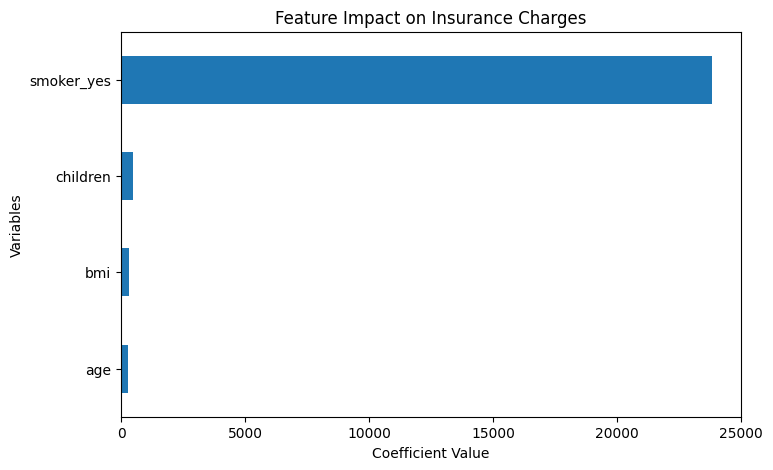

<Figure size 640x480 with 0 Axes>

In [23]:
# Extract all the coefficients except the intercept
coef = model.params.drop("const")

# Build the coefficient plot
plt.figure(figsize=(8,5))
coef.sort_values().plot(kind='barh')

# Formatting:
plt.title("Feature Impact on Insurance Charges")
plt.xlabel("Coefficient Value")
plt.ylabel("Variables")

# Save the image
plt.savefig("/Users/shenkong/Desktop/Projects/pj02_US_Medical_Insurance_Costs/images/Coefficient Plot.png")

plt.show()  # Show the plot
plt.clf()  # Clear figure

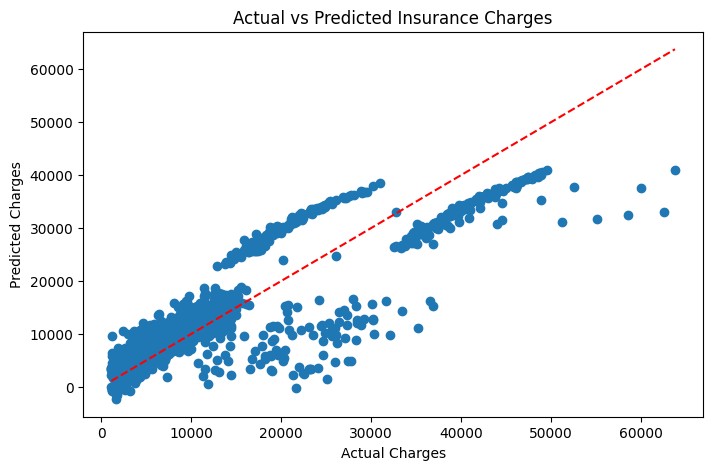

<Figure size 640x480 with 0 Axes>

In [24]:
# Build Actual vs Predicted Plot
y_pred = model.predict(X) # Predicted charges in each row

plt.figure(figsize=(8,5))
plt.scatter(y, y_pred)
# Create a reference line: y=x
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],  # Create a line from point(y.min(), y.min()) to point(y.max(), y.max())
    "r--"  # "r--" = red dashed line
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.savefig("/Users/shenkong/Desktop/Projects/pj02_US_Medical_Insurance_Costs/images/Actual_vs_Predicted_Charges.png")
plt.show()
plt.clf()

In [25]:
# Conclusion: The regression model captures general insurance cost trends reasonably well, but it systematically underestimates high-cost patients, indicating that medical expenses are influenced by nonlinear risk factors beyond simple linear relationships.

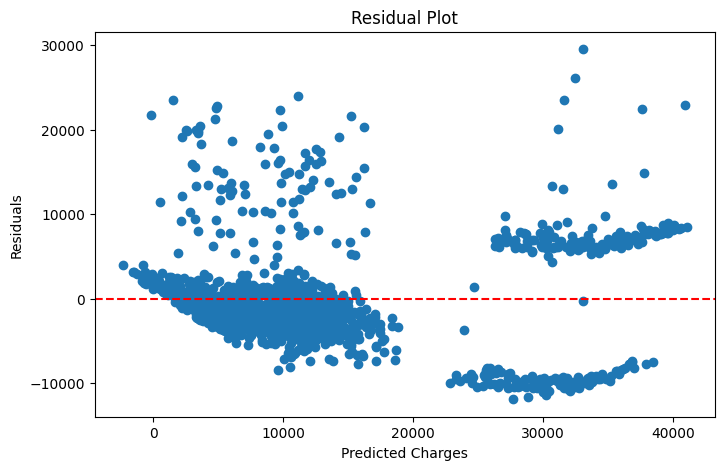

<Figure size 640x480 with 0 Axes>

In [26]:
# Build Residual Plot
residuals = y - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)

plt.axhline(y=0, color="r", linestyle="--")

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.savefig("/Users/shenkong/Desktop/Projects/pj02_US_Medical_Insurance_Costs/images/Residual_Plot.png")
plt.show()
plt.clf()

In [27]:
# The residual plot revealed clear non-random patterns and heteroscedasticity, indicating that the assumptions of linear regression were partially violated.
# Specifically, the residuals were not evenly distributed around zero and showed visible clustering structures, suggesting that the relationship between the predictors and insurance charges may not be fully linear.
# In addition, the insurance charges variable was highly right-skewed, which is common in healthcare cost data.
# To improve model stability and reduce skewness, a log transformation was applied to the target variable (charges) before rebuilding the regression model.